<a href="https://colab.research.google.com/github/Kusi12/Deep-Learning-BloodMNIST/blob/main/Blood_classification_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final: Clasificación de Células Sanguíneas utilizando Redes Neuronales Convolucionales (Arquitectura Mini-ResNet Personalizada)

**Seminario:** Deep Learning para Bioimágenes  
**Institución:** Pontificia Universidad Católica del Perú (PUCP)  
**Autor:** Poma Canchari Gianfranco, Edery Wusen Andy, Lavado Guerra Valeshka, Uñapillco Franco Kusi

---

## 1. Introducción
El análisis automatizado de imágenes biomédicas representa un desafío fundamental en la intersección de la inteligencia artificial y la atención médica. Este trabajo final aborda el problema de la clasificación multiclase de células sanguíneas periféricas a partir de imágenes microscópicas, buscando evaluar la capacidad de abstracción y generalización de arquitecturas profundas sobre imágenes de baja resolución.

## 2. Descripción del Dataset: BloodMNIST
Para este proyecto se utiliza **BloodMNIST**, un benchmark estandarizado perteneciente a la colección MedMNIST v2. Este conjunto de datos está diseñado específicamente para evaluar el rendimiento de algoritmos de *Machine Learning* de manera ligera y estandarizada.

* **Naturaleza de los datos:** Las imágenes corresponden a células normales individuales, capturadas de individuos sin infecciones, enfermedades hematológicas u oncológicas, y libres de tratamientos farmacológicos al momento de la recolección de sangre.
* **Volumen y Clases:** El dataset contiene un total de 17,092 imágenes y está organizado en 8 clases distintas de células.
* **Preprocesamiento:** Las imágenes originales fueron recortadas en el centro y posteriormente redimensionadas a un formato pequeño y estandarizado de 3x28x28 píxeles (RGB).

## 3. Metodología y Arquitectura Técnica
Este *notebook* implementa un pipeline completo de experimentación utilizando el framework PyTorch. En lugar de utilizar modelos preentrenados de gran escala, se ha diseñado una arquitectura propia optimizada para este problema:

* **Modelo Propuesto:** Se implementa una arquitectura residual personalizada desde cero (`MiPropiaResNet`). La red consta de un bloque inicial (*stem*) seguido de tres etapas de bloques residuales. Estos bloques aplican convoluciones de 3x3, normalización por lotes (*batch normalization*) y activaciones ReLU, aumentando progresivamente los mapas de características (32, 64 y 128 canales) mientras extraen patrones jerárquicos.
* **Adaptación Dimensional y Regularización:** La red está diseñada específicamente para procesar eficientemente las imágenes de 28x28 píxeles sin pérdida drástica de información espacial. Para la etapa de clasificación, se utiliza un *Adaptive Average Pooling* (GAP) seguido de una capa de *Dropout* (p=0.4) para mitigar el sobreajuste antes de la capa lineal (*Fully Connected*) que proyecta hacia las 8 clases del dataset.
* **Estrategia de Entrenamiento:** El modelo se entrena estrictamente desde cero. Se utiliza la función de pérdida *Cross-Entropy* adaptada a clasificación multiclase.
* **Optimización:** Se emplea el optimizador Adam con una tasa de aprendizaje (*learning rate*) inicial de 0.001 durante 100 épocas. Para garantizar un ajuste fino (*fine-tuning*) y una convergencia estable, se aplica un programador de tasa de aprendizaje estático (*MultiStepLR*) que aplica un factor de decaimiento de 0.1 en las épocas 50 y 75.

---
*Nota: Para garantizar la reproducibilidad y eficiencia del código, asegúrese de ejecutar este entorno utilizando aceleración por hardware (GPU T4).*

**1. Instalación de la API de MedMNIST**

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.2 MB/s eta 0:00:00


**2. Colocamos la librerias, transformaciones y dataLoaders**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models
from medmnist import BloodMNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Realizamos la transformación: Convertir a Tensor y normalizar
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Descarga de los datasets  en Train, Val, Test
print("Descargando e inicializando BloodMNIST...")
train_dataset = BloodMNIST(split='train', transform=data_transform, download=True)
val_dataset = BloodMNIST(split='val', transform=data_transform, download=True)
test_dataset = BloodMNIST(split='test', transform=data_transform, download=True)

# DataLoaders con tamaño de lote de 128, referenciando al  artículo oficial
BATCH_SIZE = 128
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total imágenes Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Descargando e inicializando BloodMNIST...


100%|██████████| 35.5M/35.5M [00:24<00:00, 1.47MB/s]


Total imágenes Train: 11959 | Val: 1712 | Test: 3421


**3. Desarrollo de Arquitectura "MiPropiaResNet" en PyTorch**



In [ ]:
import torch
import torch.nn as nn

# Definición del Bloque Residual
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

# Mini-ResNet Modificada para el trabajo final
class MiPropiaResNet(nn.Module):
    def __init__(self, in_channels: int = 3, num_classes: int = 8):
        super(MiPropiaResNet, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.stage1 = ResidualBlock(in_channels=32, out_channels=32, stride=1)
        self.stage2 = ResidualBlock(in_channels=32, out_channels=64, stride=2)
        self.stage3 = ResidualBlock(in_channels=64, out_channels=128, stride=2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Crear el dispositivo y el modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

mi_red = MiPropiaResNet(in_channels=3, num_classes=8)
print("Modelo 'MiPropiaResNet' creado correctamente.")

Usando dispositivo: cuda
Modelo 'MiPropiaResNet' creado correctamente.


**4. Fase de Entrenamiento: Optimizador Adam, Scheduler y Validación**

In [ ]:
# Bucle de Entrenamiento con Adam
import torch.optim as optim

criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(mi_red.parameters(), lr=0.001)

# Se reduce el LR para dar "pasos más pequeños" y evitar que el modelo rebote al acercarse al error mínimo.
scheduler = optim.lr_scheduler.MultiStepLR(optimizador, milestones=[50, 75], gamma=0.1)

historial_train_loss = []
historial_val_acc = []

EPOCHS = 100  # Numero referenciado del artículo
mi_red = mi_red.to(device)

print("Iniciando el entrenamiento de MiPropiaResNet (Adam)...")

for epoch in range(EPOCHS):
    mi_red.train()
    loss_acumulado = 0.0
    correctos_train = 0
    total_train = 0

    for imagenes, etiquetas in train_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.squeeze().long().to(device)

        optimizador.zero_grad()
        salidas = mi_red(imagenes)
        loss = criterio(salidas, etiquetas)

        loss.backward()
        optimizador.step()

        loss_acumulado += loss.item()
        _, predicciones = torch.max(salidas.data, 1)
        total_train += etiquetas.size(0)
        correctos_train += (predicciones == etiquetas).sum().item()

    scheduler.step()

    epoca_loss = loss_acumulado / len(train_loader)
    historial_train_loss.append(epoca_loss)

    mi_red.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.squeeze().long().to(device)
            outputs = mi_red(inputs)
            _, predicciones = torch.max(outputs, 1)
            val_corrects += (predicciones == targets).sum().item()

    val_acc = 100 * val_corrects / len(val_dataset)
    historial_val_acc.append(val_acc)

    current_lr = optimizador.param_groups[0]['lr']
    print(f'Época [{epoch+1:03d}/{EPOCHS}] | LR: {current_lr:.6f} | Error Train: {epoca_loss:.4f} | Precisión Val: {val_acc:.2f}%')

print("¡Entrenamiento completado!")
torch.save(mi_red.state_dict(), 'mi_propia_resnet.pth')

Iniciando el entrenamiento de MiPropiaResNet (Adam)...
Época [001/100] | LR: 0.001000 | Error Train: 0.6912 | Precisión Val: 59.40%
Época [002/100] | LR: 0.001000 | Error Train: 0.3609 | Precisión Val: 82.01%
Época [003/100] | LR: 0.001000 | Error Train: 0.2868 | Precisión Val: 87.38%
Época [004/100] | LR: 0.001000 | Error Train: 0.2426 | Precisión Val: 82.30%
Época [005/100] | LR: 0.001000 | Error Train: 0.2082 | Precisión Val: 87.09%
Época [006/100] | LR: 0.001000 | Error Train: 0.1914 | Precisión Val: 93.46%
Época [007/100] | LR: 0.001000 | Error Train: 0.1737 | Precisión Val: 82.83%
Época [008/100] | LR: 0.001000 | Error Train: 0.1704 | Precisión Val: 92.41%
Época [009/100] | LR: 0.001000 | Error Train: 0.1421 | Precisión Val: 78.97%
Época [010/100] | LR: 0.001000 | Error Train: 0.1280 | Precisión Val: 90.19%
Época [011/100] | LR: 0.001000 | Error Train: 0.1176 | Precisión Val: 81.54%
Época [012/100] | LR: 0.001000 | Error Train: 0.1153 | Precisión Val: 91.12%
Época [013/100] | LR:

**5. Evaluación del Rendimiento del Modelo y Análisis de Métricas de Clasificación**

Evaluando MiPropiaResNet en el conjunto de Test...

*** PRECISIÓN FINAL EN TEST: 96.00% ***

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Basophil       0.94      0.94      0.94       244
  Eosinophil       1.00      0.99      1.00       624
Erythroblast       0.99      0.97      0.98       311
          IG       0.91      0.91      0.91       579
  Lymphocyte       0.94      0.96      0.95       243
    Monocyte       0.91      0.90      0.90       284
  Neutrophil       0.97      0.97      0.97       666
    Platelet       1.00      1.00      1.00       470

    accuracy                           0.96      3421
   macro avg       0.96      0.96      0.96      3421
weighted avg       0.96      0.96      0.96      3421



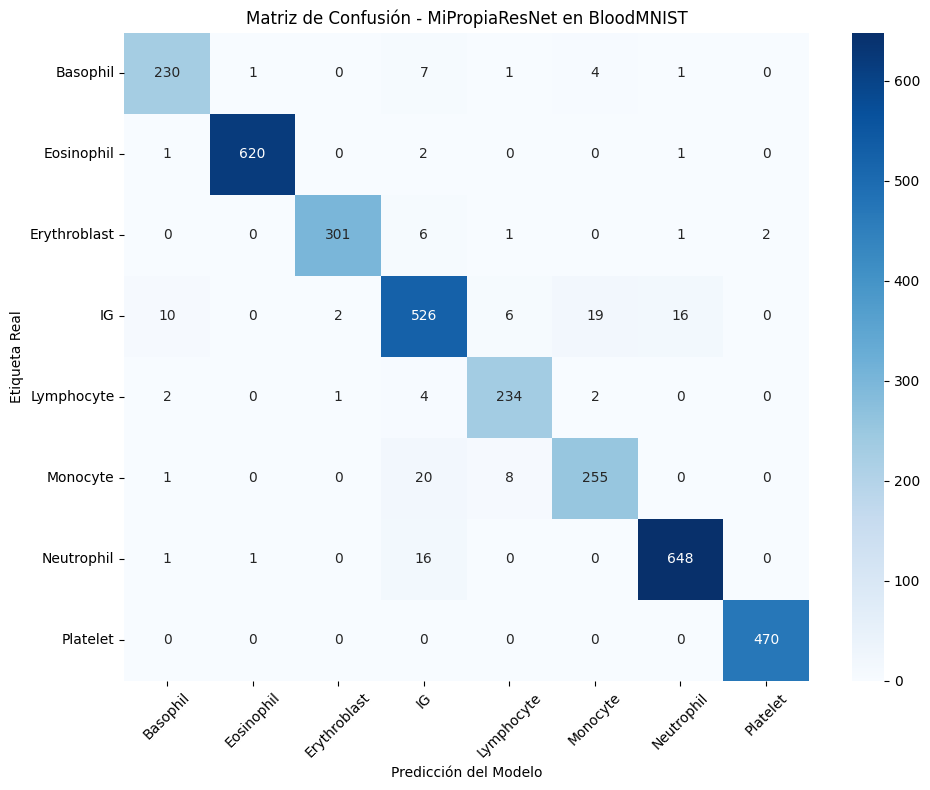

In [ ]:
# Test y Evaluación de Resultados
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch

# Cargar los pesos de nuestra arquitectura personalizada
mi_red.load_state_dict(torch.load('mi_propia_resnet.pth'))
mi_red.eval()

todas_predicciones = []
todas_etiquetas = []

print("Evaluando MiPropiaResNet en el conjunto de Test...")
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.squeeze().long().numpy()

        # Usar la nueva red para las predicciones
        outputs = mi_red(inputs)
        _, preds = torch.max(outputs, 1)

        todas_predicciones.extend(preds.cpu().numpy())
        todas_etiquetas.extend(targets)

# Resultados Globales
acc = np.mean(np.array(todas_predicciones) == np.array(todas_etiquetas))
print(f"\n*** PRECISIÓN FINAL EN TEST: {acc * 100:.2f}% ***\n")

# Nombres de las clases para BloodMNIST
nombres_clases = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']

# Reporte de Clasificación (incluye F1-Score)
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(todas_etiquetas, todas_predicciones, target_names=nombres_clases))

# Matriz de Confusión
matriz = confusion_matrix(todas_etiquetas, todas_predicciones)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')

# Título actualizado para reflejar tu propia arquitectura
plt.title('Matriz de Confusión - MiPropiaResNet en BloodMNIST')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

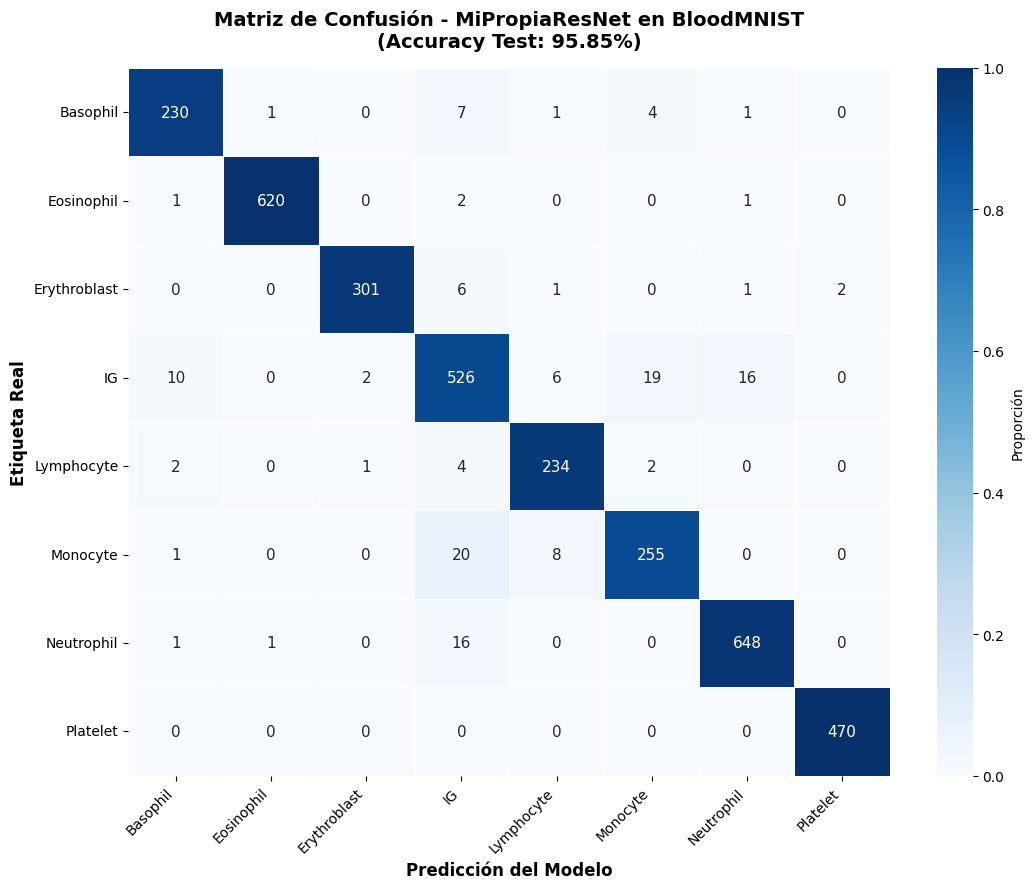

/tmp/ipykernel_760/3568912736.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_reporte.loc['accuracy', ['precision', 'recall']] = ''  # opcional: dejar vacío en vez de repetir 0.96
/tmp/ipykernel_760/3568912736.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_reporte.loc['accuracy', ['precision', 'recall']] = ''  # opcional: dejar vacío en vez de repetir 0.96


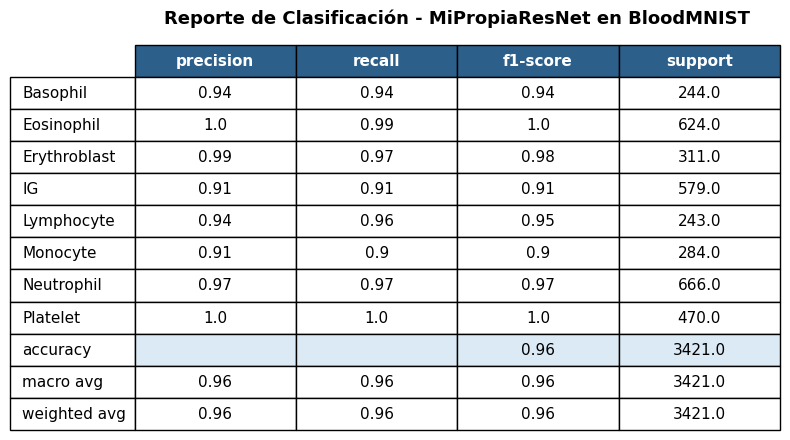

In [ ]:
# Matriz de Confusión mejorada para presentación (ppt)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

matriz = confusion_matrix(todas_etiquetas, todas_predicciones)
matriz_normalizada = matriz.astype('float') / matriz.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matriz_normalizada, annot=matriz, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases,
            cbar_kws={'label': 'Proporción'}, annot_kws={"size": 11},
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
ax.set_title('Matriz de Confusión - MiPropiaResNet en BloodMNIST\n(Accuracy Test: 95.85%)',
              fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusion_final.png', dpi=200, bbox_inches='tight')
plt.show()
# Tabla visual del Reporte de Clasificación para la expo
import pandas as pd
import matplotlib.pyplot as plt

reporte_dict = classification_report(todas_etiquetas, todas_predicciones,
                                       target_names=nombres_clases, output_dict=True)
df_reporte = pd.DataFrame(reporte_dict).transpose()
df_reporte = df_reporte.round(2)

# Modificacion de la fila 'accuracy'
df_reporte.loc['accuracy', 'support'] = df_reporte.loc['weighted avg', 'support']
df_reporte.loc['accuracy', ['precision', 'recall']] = ''  # opcional: dejar vacío en vez de repetir 0.96
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axis('off')

tabla = ax.table(cellText=df_reporte.values,
                  rowLabels=df_reporte.index,
                  colLabels=df_reporte.columns,
                  cellLoc='center', loc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 1.8)

# Colorear encabezados
for j in range(len(df_reporte.columns)):
    tabla[(0, j)].set_facecolor('#2c5f8a')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

# Resaltar la fila de accuracy general
fila_accuracy = list(df_reporte.index).index('accuracy') + 1
for j in range(len(df_reporte.columns)):
    tabla[(fila_accuracy, j)].set_facecolor('#dceaf5')

plt.title('Reporte de Clasificación - MiPropiaResNet en BloodMNIST',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('reporte_clasificacion.png', dpi=200, bbox_inches='tight')
plt.show()

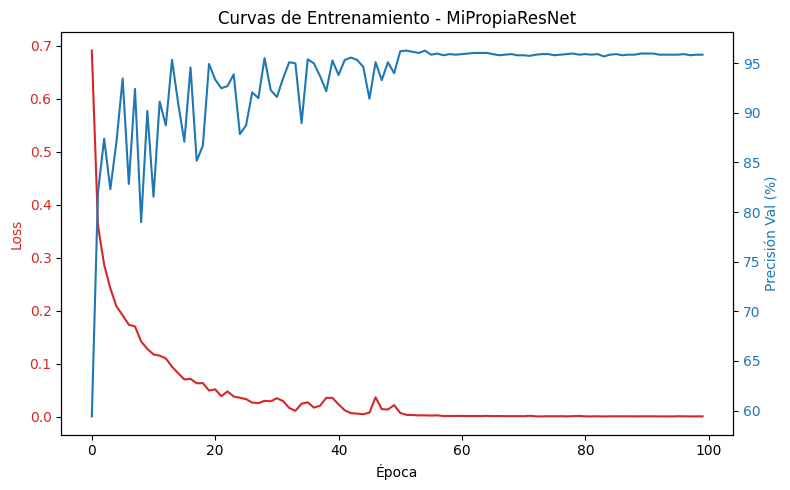

In [ ]:
# Curvas de Entrenamiento (para tu expo)
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(historial_train_loss, color='tab:red', label='Train Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(historial_val_acc, color='tab:blue', label='Val Accuracy')
ax2.set_ylabel('Precisión Val (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Curvas de Entrenamiento - MiPropiaResNet')
fig.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

---
### 🔬 Prueba Interactiva: Sube tu propia imagen
En la siguiente celda de código puedes subir **cualquier foto de una célula sanguínea** (en formato `.jpg`, `.png`, etc.) para poner a prueba las predicciones del modelo.

> **⚠️ Ojo con el margen de error:**
> Es muy probable que el modelo se equivoque o confunda las clases si subes una foto real de alta definición sacada de internet o de un laboratorio. Ten en cuenta que la calidad de los datos de entrenamiento de BloodMNIST es intencionalmente baja; todas sus imágenes están comprimidas a un tamaño de apenas **28x28 píxeles**[cite: 1].
>
> Debido a esta pérdida masiva de detalles, el resultado es solo una aproximación algorítmica. Este dataset está diseñado como un *benchmark* ligero para probar redes neuronales de forma rápida, y los propios creadores del proyecto advierten explícitamente que los resultados **no están destinados para uso clínico**[cite: 1].

¡Ejecuta la celda, dale al botón de subir archivo y mira qué predice la red!
---

Sube una imagen de una célula sanguínea para clasificarla con MiPropiaResNet:


Saving neutrophilia.jpg to neutrophilia.jpg

Procesando la imagen: "neutrophilia.jpg"...


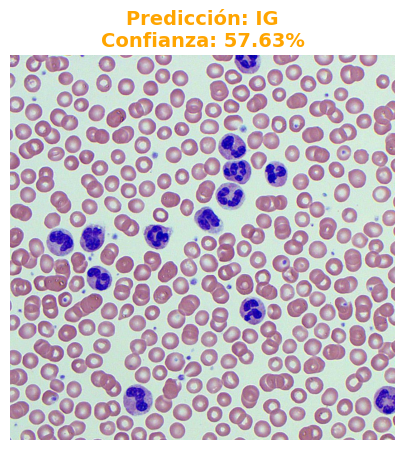

--- Top 3 Probabilidades ---
1. IG: 57.63%
2. Eosinophil: 41.15%
3. Platelet: 1.18%


In [ ]:
# Prueba Interactiva del Modelo con imagen externa
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io
import torch.nn.functional as F

# 1. Asegurarnos de usar el mejor modelo guardado y ponerlo en modo evaluación
mi_red.load_state_dict(torch.load('mi_propia_resnet.pth'))
mi_red.eval()

# 2. Definir las transformaciones
# Añadimos Resize(28, 28) por si subes una imagen más grande que las del dataset original
transformacion_interactiva = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

nombres_clases = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']

print("Sube una imagen de una célula sanguínea para clasificarla con MiPropiaResNet:")
uploaded = files.upload()

# 3. Procesar la imagen subida
for fn in uploaded.keys():
    print(f'\nProcesando la imagen: "{fn}"...')

    # Leer la imagen y asegurar que tenga 3 canales (RGB)
    imagen_bytes = uploaded[fn]
    imagen_pil = Image.open(io.BytesIO(imagen_bytes)).convert('RGB')

    # Aplicar transformaciones y añadir la dimensión del batch (1, 3, 28, 28)
    tensor_imagen = transformacion_interactiva(imagen_pil).unsqueeze(0).to(device)

    # 4. Hacer la predicción
    with torch.no_grad():
        # Usamos nuestra nueva red
        salida = mi_red(tensor_imagen)

        # Obtener las probabilidades con Softmax
        probabilidades = F.softmax(salida, dim=1)[0]

        # Obtener la clase con mayor probabilidad
        _, prediccion = torch.max(salida, 1)
        clase_predicha = nombres_clases[prediccion.item()]
        confianza = probabilidades[prediccion.item()] * 100

    # 5. Mostrar la imagen y el resultado
    plt.figure(figsize=(5, 5))
    plt.imshow(imagen_pil)
    plt.axis('off')

    # Cambiar el color del texto dependiendo de la confianza
    color_titulo = 'green' if confianza > 80 else 'orange'

    plt.title(f'Predicción: {clase_predicha}\nConfianza: {confianza:.2f}%',
              fontsize=14, color=color_titulo, fontweight='bold')
    plt.show()

    # Imprimir el top 3 de probabilidades para más detalle
    print("--- Top 3 Probabilidades ---")
    top3_prob, top3_clases = torch.topk(probabilidades, 3)
    for i in range(3):
        nombre = nombres_clases[top3_clases[i].item()]
        prob = top3_prob[i].item() * 100
        print(f"{i+1}. {nombre}: {prob:.2f}%")

---
### 🧪 Validación Aleatoria con Datos Oficiales (Archivo `.npz`)

A diferencia de la prueba anterior con imágenes externas, la siguiente celda evaluará el modelo utilizando **las imágenes originales de prueba**.

Para esto, el código extraerá aleatoriamente una muestra del conjunto `test_dataset`, el cual fue cargado directamente desde el archivo comprimido `bloodmnist.npz` proporcionado por la API de MedMNIST[cite: 1].

**¿Qué hace esta celda?**
1. **Selección aleatoria:** Escoge al azar una de las imágenes de prueba que la red neuronal **nunca vio durante su entrenamiento**.
2. **Visualización de la compresión:** Muestra la imagen en su resolución real de 28x28 píxeles[cite: 1] para observar cómo el algoritmo percibe la información.
3. **Inferencia en tiempo real:** Pone a prueba el modelo y compara la predicción matemática con la etiqueta real, marcando el resultado en verde si la predicción es correcta y en rojo si el modelo se equivoca.

*Tip: Puedes ejecutar esta celda repetidas veces ("Play") para generar y evaluar diferentes muestras de forma dinámica.*
---

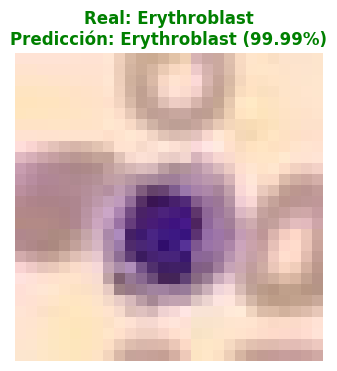

--- Top 3 Probabilidades ---
1. Erythroblast: 99.99%
2. Neutrophil: 0.01%
3. IG: 0.00%


In [ ]:
# Prueba interactiva con una imagen del archivo .npz del dataset original.
import random
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

# 1. Elegir un índice al azar de las 3,421 imágenes de prueba
indice = random.randint(0, len(test_dataset) - 1)

# 2. Extraer la imagen y su etiqueta real directamente del dataset
imagen_tensor, etiqueta_real = test_dataset[indice]
etiqueta_real = etiqueta_real.item() # Convertir el tensor a número

# Nombres de las clases
nombres_clases = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']
clase_real = nombres_clases[etiqueta_real]

# 3. Preparar la imagen para mostrarla (Deshacer la normalización de [-1, 1] a [0, 1])
# PyTorch usa (Canales, Alto, Ancho), Matplotlib usa (Alto, Ancho, Canales)
imagen_mostrar = (imagen_tensor / 2 + 0.5).permute(1, 2, 0).numpy()

# 4. Colocamos a prueba nuestra  arquitectura modificada
mi_red.eval()
with torch.no_grad():
    # Añadir la dimensión de batch (1, 3, 28, 28) y enviar a la GPU
    entrada = imagen_tensor.unsqueeze(0).to(device)

    # Inferencia con MiPropiaResNet
    salida = mi_red(entrada)

    # Obtener probabilidades
    probabilidades = F.softmax(salida, dim=1)[0]
    _, prediccion = torch.max(salida, 1)

    clase_predicha = nombres_clases[prediccion.item()]
    confianza = probabilidades[prediccion.item()] * 100

# 5. Mostrar los resultados
plt.figure(figsize=(4, 4))
plt.imshow(imagen_mostrar)
plt.axis('off')

# Condicional de acierto
color_titulo = 'green' if clase_predicha == clase_real else 'red'

plt.title(f'Real: {clase_real}\nPredicción: {clase_predicha} ({confianza:.2f}%)',
          fontsize=12, color=color_titulo, fontweight='bold')
plt.show()

# Impresion del Top 3 de probabilidades
print("--- Top 3 Probabilidades ---")
top3_prob, top3_clases = torch.topk(probabilidades, 3)
for i in range(3):
    nombre = nombres_clases[top3_clases[i].item()]
    prob = top3_prob[i].item() * 100
    print(f"{i+1}. {nombre}: {prob:.2f}%")